In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car_prices.csv")
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [3]:
df.shape

(558837, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558833 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 68.2 MB


In [5]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='str')

In [6]:
df.isnull().sum()

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

In [7]:
df['vin'] = df['vin'].replace(
    ['automatic', 'manual', 'Sedan', 'sedan'],
    np.nan
)
df['valid_vin'] = (
    df['vin'].str.len().eq(17) &
    df['vin'].str.isalnum()
)

In [8]:
state_map = {
    'ca': 'california',
    'tx': 'texas',
    'pa': 'pennsylvania',
    'mn': 'minnesota',
    'az': 'arizona',
    'wi': 'wisconsin',
    'tn': 'tennessee',
    'md': 'maryland',
    'fl': 'florida',
    'ne': 'nebraska',
    'nj': 'new jersey',
    'nv': 'nevada',
    'oh': 'ohio',
    'mi': 'michigan',
    'ga': 'georgia',
    'va': 'virginia',
    'sc': 'south carolina',
    'nc': 'north carolina',
    'in': 'indiana',
    'il': 'illinois',
    'co': 'colorado',
    'ut': 'utah',
    'mo': 'missouri',
    'ny': 'new york',
    'ma': 'massachusetts',
    'pr': 'puerto rico',
    'or': 'oregon',
    'la': 'louisiana',
    'wa': 'washington',
    'hi': 'hawaii',
    'qc': 'quebec',
    'ab': 'alberta',
    'on': 'ontario',
    'ok': 'oklahoma',
    'ms': 'mississippi',
    'nm': 'new mexico',
    'al': 'alabama',
    'ns': 'nova scotia'
}
df['state'] = df['state'].astype(str).str.strip().str.lower()
df['state'] = df['state'].replace(state_map)
print(df['state'].unique())
print(df.head())

<StringArray>
[       'california',             'texas',      'pennsylvania',
         'minnesota',           'arizona',         'wisconsin',
         'tennessee',          'maryland',           'florida',
          'nebraska',        'new jersey',            'nevada',
              'ohio',          'michigan',           'georgia',
          'virginia',    'south carolina',    'north carolina',
           'indiana',          'illinois',          'colorado',
              'utah',          'missouri',          'new york',
     'massachusetts',       'puerto rico',            'oregon',
         'louisiana',        'washington',            'hawaii',
            'quebec',           'alberta',           'ontario',
          'oklahoma',       'mississippi',        'new mexico',
           'alabama', '3vwd17aj4fm201708',       'nova scotia',
 '3vwd17aj2fm258506', '3vwd17aj3fm276741', '3vwd17aj2fm285365',
 '3vwd17aj0fm227318', '3vwd17aj6fm218641', '3vwd17aj7fm223475',
 '3vwd17aj5fm297123', '3vw

In [9]:
state_nulls = df['state'].isna().sum()
if state_nulls > 0:
    df['state'] = df['state'].fillna('Unknown')

In [10]:
print(df['state'].unique())

<StringArray>
[       'california',             'texas',      'pennsylvania',
         'minnesota',           'arizona',         'wisconsin',
         'tennessee',          'maryland',           'florida',
          'nebraska',        'new jersey',            'nevada',
              'ohio',          'michigan',           'georgia',
          'virginia',    'south carolina',    'north carolina',
           'indiana',          'illinois',          'colorado',
              'utah',          'missouri',          'new york',
     'massachusetts',       'puerto rico',            'oregon',
         'louisiana',        'washington',            'hawaii',
            'quebec',           'alberta',           'ontario',
          'oklahoma',       'mississippi',        'new mexico',
           'alabama', '3vwd17aj4fm201708',       'nova scotia',
 '3vwd17aj2fm258506', '3vwd17aj3fm276741', '3vwd17aj2fm285365',
 '3vwd17aj0fm227318', '3vwd17aj6fm218641', '3vwd17aj7fm223475',
 '3vwd17aj5fm297123', '3vw

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  str    
 2   model         548438 non-null  str    
 3   trim          548186 non-null  str    
 4   body          545642 non-null  str    
 5   transmission  493485 non-null  str    
 6   vin           558811 non-null  str    
 7   state         558837 non-null  str    
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  str    
 11  interior      558088 non-null  str    
 12  seller        558837 non-null  str    
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  str    
 16  valid_vin     558837 non-null  bool   
dtypes: bool(1), float64(4), int64(1), str(11)
memory usage: 68.

In [12]:
df['make'] = df['make'].str.strip()
df['make'] = df['make'].str.title()
df['make'] = df['make'].replace({
    'Bmw': 'BMW',
    'Gmc': 'GMC',
    'Infiniti': 'INFINITI',
    'Land Rover': 'LAND ROVER',
    'Mercedes-Benz': 'MERCEDES-BENZ'
})
df['make'] = df['make'].fillna('Unknown')

In [13]:
df['model'] = (
    df['model']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)
df['model'] = df['model'].replace({
    'F150': 'F-150',
    'F250': 'F-250',
    'F350': 'F-350'
})
df['model'] = df['model'].fillna('Unknown')

In [14]:
df['trim'] = (
    df['trim']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
df['trim'] = df['trim'].fillna('Unknown')


In [15]:
df['body'] = (
    df['body']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)
df['body'] = df['body'].replace({
    'Navitgation': 'Navigation'
})
df['body'] = df['body'].fillna('Unknown')
print(df['body'].unique())

<StringArray>
[                    'Suv',                   'Sedan',
             'Convertible',                   'Coupe',
                   'Wagon',               'Hatchback',
                'Crew Cab',                 'G Coupe',
                 'G Sedan',           'Elantra Coupe',
           'Genesis Coupe',                 'Minivan',
                 'Unknown',                     'Van',
              'Double Cab',             'Crewmax Cab',
              'Access Cab',                'King Cab',
               'Supercrew',               'Cts Coupe',
            'Extended Cab',            'E-Series Van',
                'Supercab',             'Regular Cab',
           'G Convertible',                    'Koup',
                'Quad Cab',             'Cts-V Coupe',
         'G37 Convertible',                'Club Cab',
                 'Xtracab',         'Q60 Convertible',
               'Cts Wagon',               'G37 Coupe',
                'Mega Cab',              'Cab Plus 

In [16]:
df['transmission'] = (
    df['transmission']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.lower()
)
df.loc[
    df['transmission'].isin(['sedan', 'coupe', 'suv', 'wagon', 'convertible']),
    'transmission'
] = np.nan
df['transmission'] = df['transmission'].replace({
    'auto': 'automatic',
    'a/t': 'automatic',
    'm/t': 'manual'
})
df['transmission'] = df['transmission'].dropna()

In [17]:
df['vin'] = df['vin'].astype(str).str.strip().str.upper()
invalid_vins = ['AUTOMATIC', 'MANUAL', 'SEDAN']
df.loc[df['vin'].isin(invalid_vins), 'vin'] = np.nan
df.loc[df['vin'].notna() & (df['vin'].str.len() != 17), 'vin'] = np.nan
print(df['vin'].isna().sum(), "missing VINs")
print(df['vin'].unique())

26 missing VINs
<StringArray>
['5XYKTCA69FG566472', '5XYKTCA69FG561319', 'WBA3C1C51EK116351',
 'YV1612TB4F1310987', 'WBA6B2C57ED129731', '1N4AL3AP1FN326013',
 'WBSFV9C51ED593089', '1G1PC5SB2E7128460', 'WAUFFAFL3EN030343',
 '2G1FB3D37E9218789',
 ...
 '1C4RJFAG0EC466276', '2C4RDGBG1CR349287', '5NPDH4AE7CH106397',
 '3N1AB6AP3CL622485', 'WBAFR1C53BC744672', 'KNALW4D4XF6019304',
 '3C6TD5ET6CG112407', '5UXZW0C58CL668465', '1N4AL3AP0FC216050',
 '1FTFW1ET2EKE87277']
Length: 550297, dtype: str


In [18]:
df['condition'] = pd.to_numeric(df['condition'], errors='coerce')
df.loc[
    (df['condition'] < 0) |
    (df['condition'] > 50),
    'condition'
] = np.nan
df['condition'] = df['condition'].astype('Int64')

In [19]:
df['odometer'] = pd.to_numeric(df['odometer'], errors='coerce')
df.loc[df['odometer'] < 0, 'odometer'] = np.nan
df.loc[df['odometer'] == 999999, 'odometer'] = np.nan
df['odometer'] = df['odometer'].astype('Int64')

In [20]:
df['color'] = (
    df['color']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)
numeric_color_mask = df['color'].str.match(r'^\d+$', na=False)
df.loc[numeric_color_mask, 'color'] = np.nan
df['color'] = df['color'].replace('—', np.nan)
df['color'] = df['color'].fillna('Unknown')

In [21]:
df['interior'] = (
    df['interior']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)
df['interior'] = df['interior'].replace('—', np.nan)
df['interior'] = df['interior'].fillna('Unknown')

In [22]:
df['seller'] = (
    df['seller']
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
    .fillna('Unknown Seller')
)

In [23]:
df['mmr'] = pd.to_numeric(df['mmr'], errors='coerce')
df.loc[df['mmr'] < 100, 'mmr'] = np.nan
df.loc[df['mmr'] < 0, 'mmr'] = np.nan

In [24]:
df['sellingprice'] = pd.to_numeric(df['sellingprice'], errors='coerce')
df.loc[df['sellingprice'] < 0, 'sellingprice'] = np.nan
df.loc[df['sellingprice'] < 10, 'sellingprice'] = np.nan

In [25]:
df['saledate'] = pd.to_datetime(
    df['saledate'].str.replace(r'GMT.*', '', regex=True),
    errors='coerce'
)

In [26]:
df['sale_year'] = df['saledate'].dt.year
df['sale_month'] = df['saledate'].dt.month
df['sale_day'] = df['saledate'].dt.day

In [27]:
df['saledate'].unique()

<DatetimeArray>
['2014-12-16 12:30:00', '2015-01-15 04:30:00', '2015-01-29 04:30:00',
 '2014-12-18 12:30:00', '2014-12-30 12:00:00', '2014-12-17 12:30:00',
 '2014-12-16 13:00:00', '2014-12-18 12:00:00', '2015-01-20 04:00:00',
 '2014-12-16 12:00:00',
 ...
 '2015-06-19 01:45:00', '2015-06-30 04:00:00', '2015-06-18 04:40:00',
 '2015-06-23 08:00:00', '2015-06-24 04:45:00', '2015-06-25 07:10:00',
 '2015-07-08 09:05:00', '2015-07-07 08:45:00', '2015-07-02 13:20:00',
 '2015-07-08 09:45:00']
Length: 3746, dtype: datetime64[us]

In [28]:
print(df['saledate'].dtype)
print(df['saledate'].isna().sum())
print(df['saledate'].min())
print(df['saledate'].max())

datetime64[us]
38
2014-01-01 09:15:00
2015-07-21 02:30:00


In [29]:
df = df.dropna(subset=['saledate'])
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df.loc[~df['year'].between(1980, 2025), 'year'] = np.nan
print(df['year'].isna().sum(), "missing year values")
print(df['year'].unique())
df['year'] = df['year'].astype('int64')


0 missing year values
[2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1995. 1996. 1997. 1987. 1994. 1993.
 1992. 1989. 1991. 1990. 1986. 1985. 1988. 1984. 1982. 1983.]


In [30]:
df['condition'] = df['condition'].fillna(df['condition'].median())
df['odometer'] = df['odometer'].fillna(df['odometer'].median())
df.isnull().sum()

year                0
make                0
model               0
trim                0
body                0
transmission    65351
vin                 0
state               0
condition           0
odometer            0
color               0
interior            0
seller              0
mmr                97
sellingprice        4
saledate            0
valid_vin           0
sale_year           0
sale_month          0
sale_day            0
dtype: int64

In [31]:
for col in df.columns:
    print("=" * 50)
    print(f"Column: {col}")
    print(f"Unique Values: {df[col].nunique(dropna=False)}")
    print(df[col].unique())
    print()

Column: year
Unique Values: 34
[2015 2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002
 2001 2000 1999 1998 1995 1996 1997 1987 1994 1993 1992 1989 1991 1990
 1986 1985 1988 1984 1982 1983]

Column: make
Unique Values: 67
<StringArray>
[          'Kia',           'BMW',         'Volvo',        'Nissan',
     'Chevrolet',          'Audi',          'Ford',       'Hyundai',
         'Buick',      'Cadillac',         'Acura',         'Lexus',
      'INFINITI',          'Jeep', 'MERCEDES-BENZ',    'Mitsubishi',
         'Mazda',          'Mini',    'LAND ROVER',       'Lincoln',
        'Jaguar',    'Volkswagen',        'Toyota',        'Subaru',
         'Scion',       'Porsche',       'Unknown',         'Dodge',
          'Fiat',      'Chrysler',       'Ferrari',         'Honda',
           'GMC',           'Ram',         'Smart',       'Bentley',
       'Pontiac',        'Saturn',      'Maserati',       'Mercury',
        'Hummer',     'Landrover',      'Mercedes',     'Gm

In [32]:
df['year'] = df['year'].astype('Int64')
print(df.shape)
print(df.isnull().sum().sum())
print(df.dtypes)

(558799, 20)
65452
year                     Int64
make                       str
model                   string
trim                       str
body                       str
transmission               str
vin                        str
state                      str
condition                Int64
odometer                 Int64
color                      str
interior                   str
seller                     str
mmr                    float64
sellingprice           float64
saledate        datetime64[us]
valid_vin                 bool
sale_year              float64
sale_month             float64
sale_day               float64
dtype: object


In [33]:
df[['sellingprice','mmr','odometer','condition','year']].describe()

,sellingprice,mmr,odometer,condition,year
count,558795.000000,558702.000000,558799.0,558799.0,558799.0
mean,13611.453723,13771.759722,68199.011172,30.763892,2010.038633
std,9749.695089,9679.118759,52336.409347,13.275258,3.96683
min,100.000000,100.000000,1.0,1.0,1982.0
25%,6900.000000,7100.000000,28378.0,24.0,2007.0
50%,12100.000000,12250.000000,52250.0,35.0,2012.0
75%,18200.000000,18300.000000,99083.0,41.0,2013.0
max,230000.000000,182000.000000,980113.0,49.0,2015.0


In [34]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"Outliers: {len(outliers)}")
    print(outliers[[col]].head())


Column: year
Outliers: 4021
      year
5147  1995
5148  1996
5150  1995
5151  1997
5152  1997

Column: condition
Outliers: 0
Empty DataFrame
Columns: [condition]
Index: []

Column: odometer
Outliers: 10332
      odometer
1666    227606
2038    236928
2470    291087
2682    237880
2822    312235

Column: mmr
Outliers: 16315
        mmr
4   66000.0
6   69000.0
10  47300.0
17  37100.0
19  68000.0

Column: sellingprice
Outliers: 16354
    sellingprice
4        67000.0
6        65000.0
10       49750.0
17       40000.0
19       67200.0

Column: sale_year
Outliers: 53727
   sale_year
0     2014.0
1     2014.0
4     2014.0
5     2014.0
6     2014.0

Column: sale_month
Outliers: 0
Empty DataFrame
Columns: [sale_month]
Index: []

Column: sale_day
Outliers: 0
Empty DataFrame
Columns: [sale_day]
Index: []


In [35]:
Q1 = df['sellingprice'].quantile(0.25)
Q3 = df['sellingprice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df.loc[(df['sellingprice'] < lower) | (df['sellingprice'] > upper), 'sellingprice'] = np.nan
print(f"Lower limit: {lower}")
print(f"Upper limit: {upper}")
print(f"Missing values: {df['sellingprice'].isna().sum()}")

Lower limit: -10050.0
Upper limit: 35150.0
Missing values: 16358


In [36]:

print(df[df['sellingprice'] > 35150][['make', 'sellingprice']].sort_values('sellingprice', ascending=False).head(20))

Empty DataFrame
Columns: [make, sellingprice]
Index: []


In [37]:
Q1 = df['odometer'].quantile(0.25)
Q3 = df['odometer'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df.loc[(df['odometer'] < lower) | (df['odometer'] > upper), 'odometer'] = np.nan
print(f"Lower limit: {lower}")
print(f"Upper limit: {upper}")
print(f"Missing values: {df['odometer'].isna().sum()}")

Lower limit: -77679.5
Upper limit: 205140.5
Missing values: 10332


In [38]:
Q1 = df['mmr'].quantile(0.25)
Q3 = df['mmr'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df.loc[(df['mmr'] < lower) | (df['mmr'] > upper), 'mmr'] = np.nan
print(f"Lower limit: {lower}")
print(f"Upper limit: {upper}")
print(f"Missing values: {df['mmr'].isna().sum()}")

Lower limit: -9700.0
Upper limit: 35100.0
Missing values: 16412


In [39]:
Q1 = df['condition'].quantile(0.25)
Q3 = df['condition'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df.loc[(df['condition'] < lower) | (df['condition'] > upper), 'condition'] = np.nan
print(f"Lower limit: {lower}")
print(f"Upper limit: {upper}")
print(f"Missing values: {df['condition'].isna().sum()}")

Lower limit: -1.5
Upper limit: 66.5
Missing values: 0


In [40]:
Q1 = df['year'].quantile(0.25)
Q3 = df['year'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df.loc[(df['year'] < lower) | (df['year'] > upper), 'year'] = np.nan
print(f"Lower limit: {lower}")
print(f"Upper limit: {upper}")
print(f"Missing values: {df['year'].isna().sum()}")

Lower limit: 1998.0
Upper limit: 2022.0
Missing values: 4021


In [41]:

cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
for col in cols:
    print(f"{col}: {df[col].isna().sum()} missing values")
print(f"\nTotal rows: {df.shape[0]}")

year: 4021 missing values
condition: 0 missing values
odometer: 10332 missing values
mmr: 16412 missing values
sellingprice: 16358 missing values

Total rows: 558799


In [42]:
df = df.dropna(subset=['year', 'odometer', 'mmr', 'sellingprice'])
print(f"Remaining rows: {df.shape[0]}")
print(f"Remaining columns: {df.shape[1]}")

Remaining rows: 527516
Remaining columns: 20


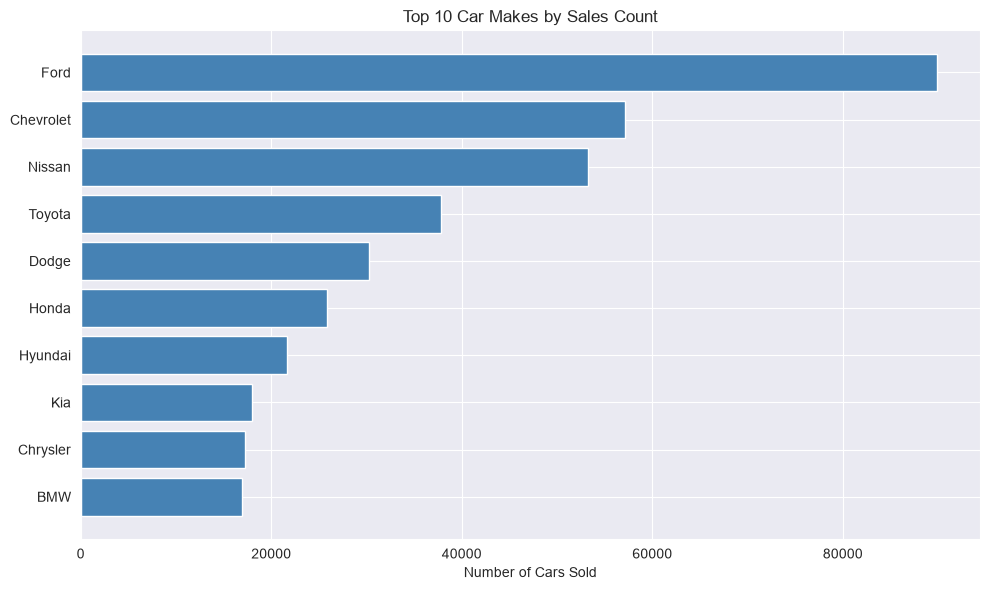

make
Ford         89898
Chevrolet    57105
Nissan       53212
Toyota       37850
Dodge        30249
Honda        25829
Hyundai      21627
Kia          17973
Chrysler     17275
BMW          16970
Name: count, dtype: int64


In [43]:
top_makes = df['make'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_makes.index[::-1], top_makes.values[::-1], color='steelblue')
plt.title('Top 10 Car Makes by Sales Count')
plt.xlabel('Number of Cars Sold')
plt.tight_layout()
plt.show()
print(top_makes)

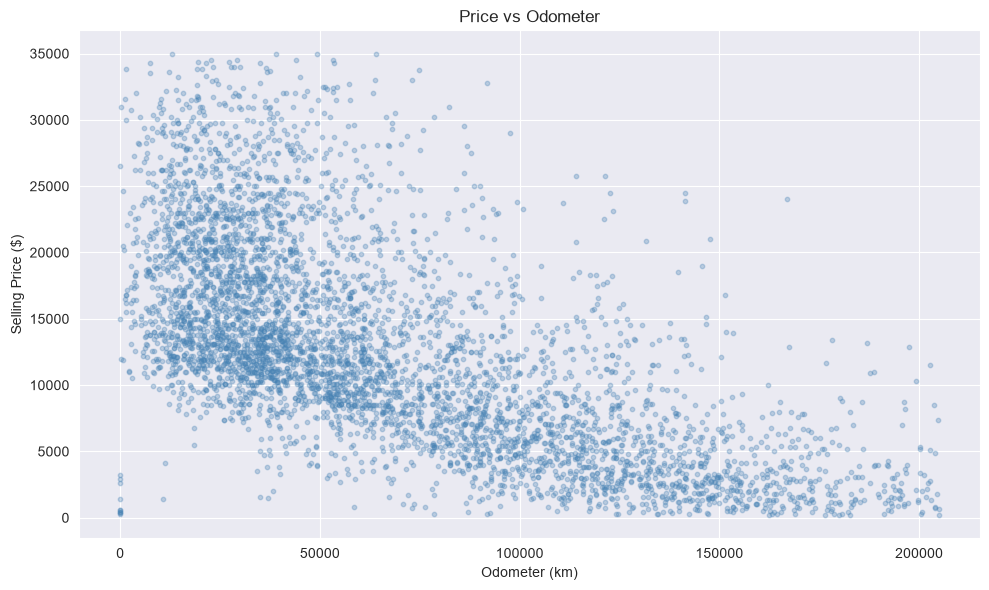

In [44]:
sample = df.sample(5000, random_state=42)
plt.figure(figsize=(10, 6))
plt.scatter(sample['odometer'], sample['sellingprice'],
            alpha=0.3, color='steelblue', s=10)
plt.title('Price vs Odometer')
plt.xlabel('Odometer (km)')
plt.ylabel('Selling Price ($)')
plt.tight_layout()
plt.show()

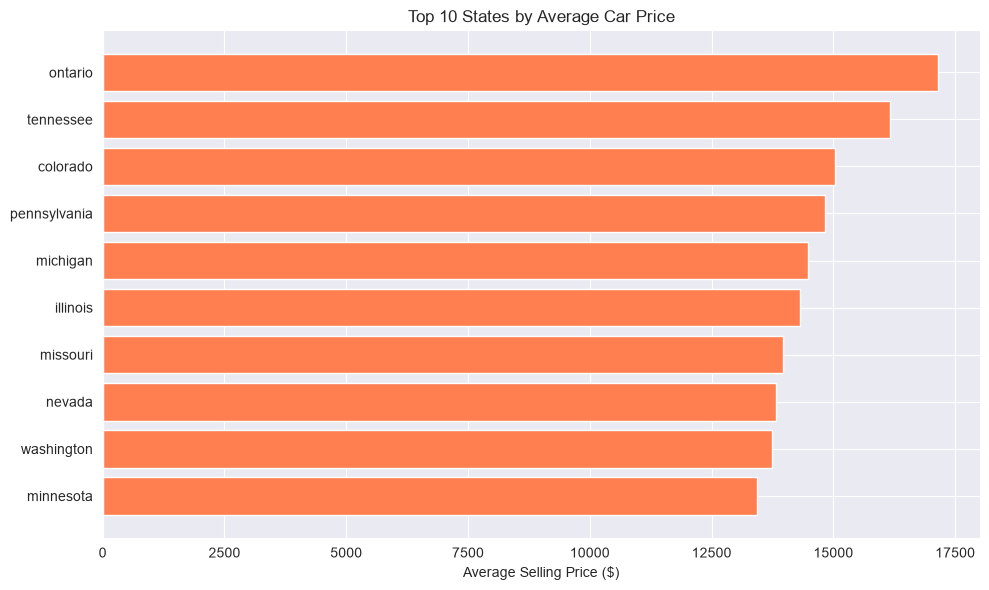

state
ontario         17152.405388
tennessee       16153.051282
colorado        15034.328074
pennsylvania    14830.816336
michigan        14477.735134
illinois        14323.329799
missouri        13958.261600
nevada          13814.860964
washington      13732.906690
minnesota       13422.563974
Name: sellingprice, dtype: float64


In [45]:
state_price = df.groupby('state')['sellingprice'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
plt.barh(state_price.index[::-1], state_price.values[::-1], color='coral')
plt.title('Top 10 States by Average Car Price')
plt.xlabel('Average Selling Price ($)')
plt.tight_layout()
plt.show()
print(state_price)

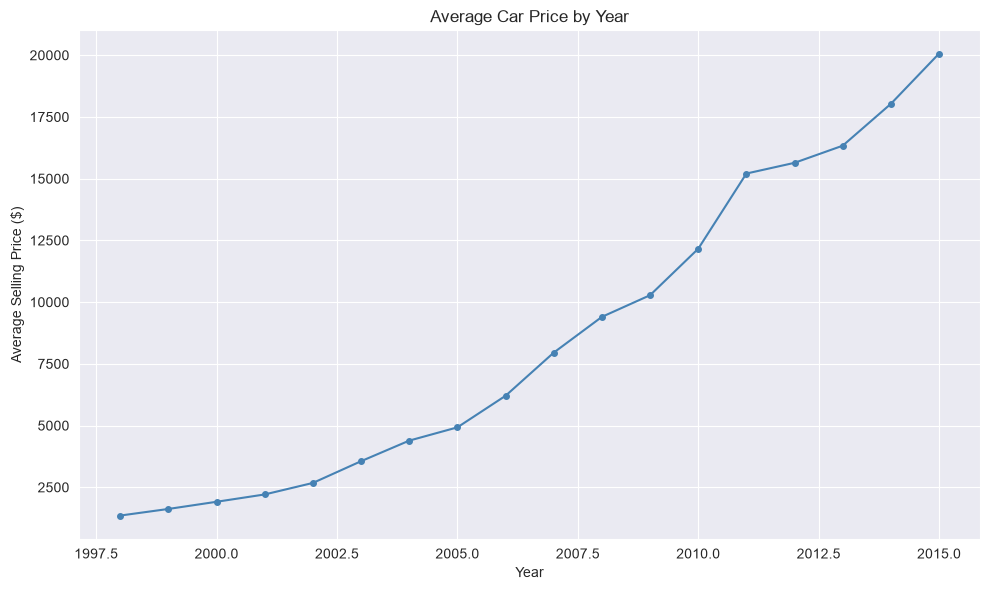

In [46]:
year_price = df.groupby('year')['sellingprice'].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
plt.plot(year_price.index, year_price.values,
         color='steelblue', marker='o', markersize=4)
plt.title('Average Car Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Selling Price ($)')
plt.tight_layout()
plt.show()

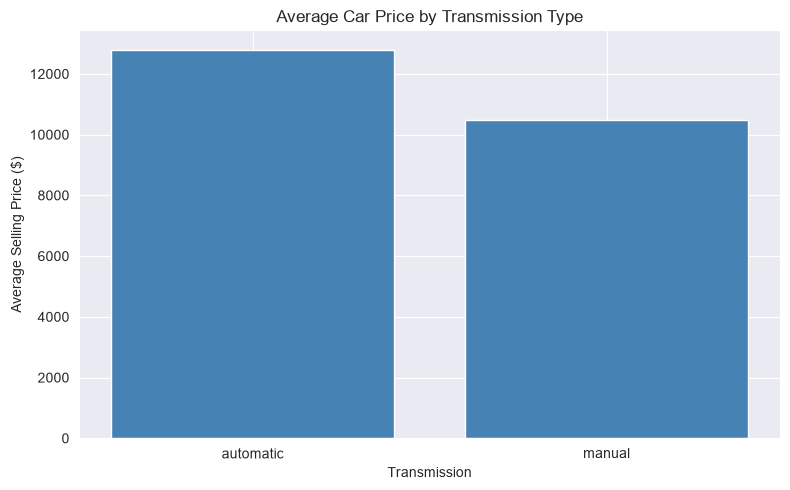

transmission
automatic    12789.375505
manual       10468.284569
Name: sellingprice, dtype: float64


In [47]:
trans_price = df.groupby('transmission')['sellingprice'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(trans_price.index, trans_price.values, color='steelblue')
plt.title('Average Car Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price ($)')
plt.tight_layout()
plt.show()
print(trans_price)




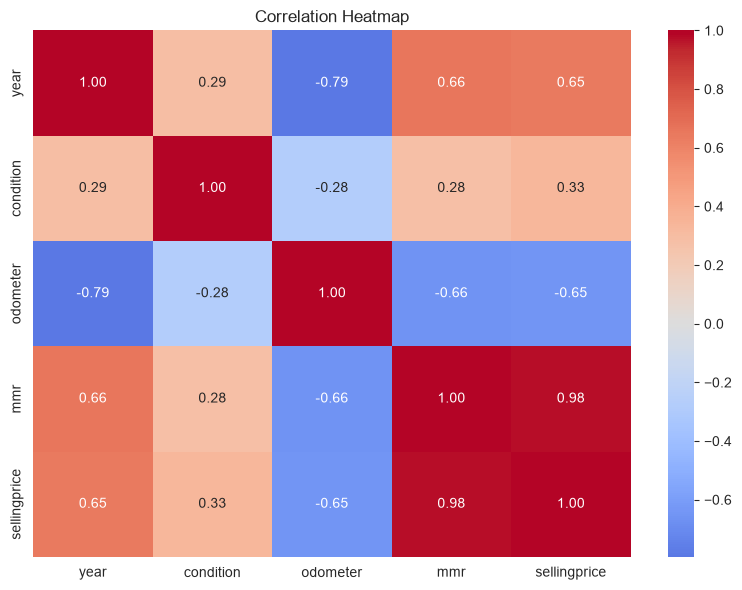

In [48]:
num_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()